In [1]:
import numpy as np

from datetime import datetime, timedelta
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    KnownTurnRate,
)
from stonesoup.types.groundtruth import GroundTruthState, GroundTruthPath

from nereus.platform import TowedArrayPlatform
from nereus.models.environment import Munk, Constant, Linear, FlatBathymetry
from nereus.models.propagation import CylindricalAcousticPropagationModel, rtrsAcousticPropagationModel
from nereus.signal.anthropogenic import BroadbandShipSignal
from nereus.signal.ambient import ColouredNoise
from nereus.simulator import BroadbandPassiveSonarArraySimulator
from nereus.sigproc import DelayAndSumBeamformer, SteeringCalculator, MinimumVarianceDistortionlessResponseBeamformer
from nereus.detector import CFARDetector, PassiveSonarDetector, PeakDetector
from nereus.plotter import BearingsPlotter

seed = 12
print(f"seed: {seed}")
np.random.seed(seed)

def random_start_vector(X, Vx, Y, Vy):
    return np.array([
        np.random.uniform(X[0], X[1]),
        np.random.uniform(Vx[0], Vx[1]),
        np.random.uniform(Y[0], Y[1]),
        np.random.uniform(Vy[0], Vy[1]),
        -5,
        0,
    ])

def generate_random_maneuvers(total_duration_s, timestep_s, min_leg_duration_s=60, max_leg_duration_s=300, maneuver_prob=0.5):
    """Generate random sequence of straight/turn maneuvers. manoeuvrers
    
    Args:
        total_duration_s: Total simulation time in seconds
        timestep_s: Simulation timestep in seconds
        min_leg_duration_s: Minimum duration for each leg
        max_leg_duration_s: Maximum duration for each leg
        maneuver_prob: Probability of performing a turn maneuver at each leg
    
    Returns:
        maneuver_models: List of transition models (3D)
        maneuver_durations: List of timedelta durations for each leg
        maneuver_descriptions: List of string descriptions for logging
    """
    maneuver_models = []
    maneuver_durations = []
    maneuver_descriptions = []
    
    current_time = 0.0
    
    while current_time < total_duration_s - min_leg_duration_s:
        # Random leg duration (round to nearest timestep)
        leg_duration = np.random.uniform(min_leg_duration_s, max_leg_duration_s)
        leg_duration = round(leg_duration / timestep_s) * timestep_s
        leg_duration = min(leg_duration, total_duration_s - current_time)
        
        # Decide maneuver
        if np.random.rand() > maneuver_prob:
            # Straight leg
            model = CombinedLinearGaussianTransitionModel([
                ConstantVelocity(0.0), 
                ConstantVelocity(0.0), 
                ConstantVelocity(0.0)
            ])
            description = f"Straight ({leg_duration:.0f}s)"
        else:
            # Random turn: -90° to +90° (negative = right turn, positive = left turn)
            turn_angle_deg = np.random.uniform(-90, 90)
            turn_rate_deg_per_s = 1.0  # Standard turn rate
            
            # Calculate actual turn duration based on angle
            turn_duration_s = abs(turn_angle_deg) / turn_rate_deg_per_s
            turn_duration_s = round(turn_duration_s / timestep_s) * timestep_s
            leg_duration = min(turn_duration_s, total_duration_s - current_time)
            
            turn_rate_rad = np.deg2rad(np.sign(turn_angle_deg) * turn_rate_deg_per_s)
            
            turning_2d = KnownTurnRate(
                turn_rate=turn_rate_rad,
                turn_noise_diff_coeffs=np.array([0.0, 0.0])
            )
            
            model = CombinedLinearGaussianTransitionModel([
                turning_2d,
                ConstantVelocity(0.0)  # Constant depth
            ])
            
            direction = "Left" if turn_angle_deg > 0 else "Right"
            description = f"{direction} Turn {abs(turn_angle_deg):.0f}° ({leg_duration:.0f}s)"
        
        maneuver_models.append(model)
        maneuver_durations.append(timedelta(seconds=leg_duration))
        maneuver_descriptions.append(description)
        
        current_time += leg_duration
    
    return maneuver_models, maneuver_durations, maneuver_descriptions

seed: 12


/home/fin/miniconda3/envs/nereus-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SIMULATION PARAMETERS

In [2]:
# ============================================================================
# SIMULATION PARAMETERS
# ============================================================================

SIM_LENGTH = 1500 # seconds
SIM_RATE = 5.0 # seconds

Xlim = [-6000, 6000]
Ylim = [-6000, 6000]

NUM_TARGETS = 10

SIM_PARAMS = {
    "start_time":datetime.now().replace(hour=0, minute=0, second=0, microsecond=0),
    "time_interval":timedelta(seconds=SIM_RATE),
    "num_steps":int(SIM_LENGTH / SIM_RATE),
}

total_duration_s = SIM_PARAMS["num_steps"] * SIM_PARAMS["time_interval"].total_seconds()
print(f"Total simulation duration: {total_duration_s} seconds")
print(f"Number of timesteps: {SIM_PARAMS['num_steps']}, Timestep interval: {SIM_PARAMS['time_interval'].total_seconds()} seconds")

SHIP_PARAMS = {
    # "start_vector": random_start_vector(Xlim, [-5,5], Ylim, [-5, 5]), 
    "start_vector": np.array([0.0, -5.0, 0.0, 0.0, 5.0, 0.0]),
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
}

ARRAY_PARAMS = {
    "num_sensors": 250,  
    "tow_cable_length": 100.0,
    "sensor_spacing": 1.0,
    "array_depth": -30.0,
}

TARGETS = []
TARGET_MANEUVERS = []

for i in range(NUM_TARGETS):
    target_maneuver_models, target_maneuver_timesteps, target_maneuver_descriptions = generate_random_maneuvers(
        total_duration_s=total_duration_s,
        timestep_s=SIM_PARAMS["time_interval"].total_seconds(),
        min_leg_duration_s=60,
        max_leg_duration_s=300,
        maneuver_prob=0.20 
    )

    TARGET_PARAMS = {
        "start_vector": random_start_vector(Xlim, [-10.5,10.5], Ylim, [-10.5, 10.5]),  
        "position_mapping": [0, 2, 4],
        "velocity_mapping": [1, 3, 5],
        "transition_model": CombinedLinearGaussianTransitionModel(
            [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
        ),
        "amplitudes_upa": 10 ** (np.random.uniform(87, 102, 4) / 20),
        "frequencies_hz": np.random.uniform(25.0, 200.0, 4),
        "phases_rad": np.random.uniform(0, 2 * np.pi, 4),
        "tonal_bandwidth_hz": np.random.uniform(0.5, 2.0),
        "noise_amplitude_upa":10 ** (np.random.uniform(75, 85) / 20),
        "noise_spectral_exponent":-1.0,
    }
    TARGETS.append(TARGET_PARAMS)
    TARGET_MANEUVERS.append({
        "models": target_maneuver_models,
        "timesteps": target_maneuver_timesteps,
        "descriptions": target_maneuver_descriptions
    })

SIGNAL_PARAMS = {
    "duration_s": total_duration_s,
    "sampling_rate_hz": 500.0, 
    "frame_len": 500,
    "hop_factor": 2,
    "fade_in_ms": 1000.0,
}

AMBIENT_NOISE_PARAMS = {
    "amplitude_upa": 10 ** (np.random.uniform(50, 55) / 20),  
    "spectral_exponent": -1,  
}

PROP_PARAMS = {
    # "ssp": Constant(speed=1500.0), 
    "ssp": Linear(surface_speed=1500.0, gradient=0.2),
    # "ssp": Munk(),
    "attenuation_factor": 0.5, 
    "bathymetry": FlatBathymetry(depth=-150.0),
    # "bathymetry": FlatBathymetry(depth=-5000.0),
    "step_m": 20.0,
    "azimuth_search_width": 2.0,
    "azimuth_resolution": 0.5,
    "elevation_range": (-25.0, 25.0),
    "elevation_resolution": 1.0,
}

# fmin and fmax only for broadband_power DAS and MVDR
BF_PARAMS = {
    "beamformer_type": "DAS",
    "shading": None,    # shading is only for DAS, does nothing with MVDR
    # "shading": "blackman",
    "domain": "broadband_power",  # "time", "frequency", or "broadband_power" for DAS only
    "steering_azimuths_rad": np.linspace(-np.pi, np.pi, 181), 
    "fmin": 25.0,
    "fmax": 200.0,
    # "fmin": None,
    # "fmax": None,
}

# Detection parameters
DET_PARAMS = {
    "cfar_detector": {
        "num_guard_cells": 2,
        "num_training_cells": 10,
        "threshold_factor": 1.10,  
    },
    "peak_detector": {
        "distance": 3,  
    }
}

Total simulation duration: 1500.0 seconds
Number of timesteps: 300, Timestep interval: 5.0 seconds


# SETUP

In [3]:
# ============================================================================
# SETUP
# ============================================================================

# Generate random maneuvers for platform
maneuver_models, maneuver_durations, maneuver_descriptions = generate_random_maneuvers(
    total_duration_s=total_duration_s,
    timestep_s=SIM_PARAMS["time_interval"].total_seconds(),
    min_leg_duration_s=60,
    max_leg_duration_s=300,  
    maneuver_prob=0.25
)

# HACK to Convert left turns to right turns (makes this seed less cursed (less targets end up in the endfire))
for i, (model, desc) in enumerate(zip(maneuver_models, maneuver_descriptions)):
    if hasattr(model.model_list[0], 'turn_rate') and model.model_list[0].turn_rate > 0:
        maneuver_models[i] = CombinedLinearGaussianTransitionModel([
            KnownTurnRate(turn_rate=-model.model_list[0].turn_rate, turn_noise_diff_coeffs=np.array([0.0, 0.0])),
            ConstantVelocity(0.0)
        ])
        maneuver_descriptions[i] = desc.replace("Left", "Right")

print(f"  Platform Maneuvers ({len(maneuver_models)} total):")
for i, desc in enumerate(maneuver_descriptions):
    print(f"    {i+1}. {desc} @ timestep {maneuver_durations[i]}")
print()

# Create platform
print("Creating platform...")
initial_state = GroundTruthState(
    SHIP_PARAMS["start_vector"], timestamp=SIM_PARAMS["start_time"]
)

platform = TowedArrayPlatform(
    states=[initial_state],
    position_mapping=SHIP_PARAMS["position_mapping"],
    velocity_mapping=SHIP_PARAMS["velocity_mapping"],
    transition_models=maneuver_models,
    transition_times=maneuver_durations,
    num_sensors=ARRAY_PARAMS["num_sensors"],
    cable_length_m=ARRAY_PARAMS["tow_cable_length"],
    sensor_spacing_m=ARRAY_PARAMS["sensor_spacing"],
    array_depth_m=ARRAY_PARAMS["array_depth"],
)


# Move platform through all timesteps with maneuver transitions
print("Moving platform through scenario...")
for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    platform.move(new_time)

# Create target trajectories
print(f"Creating {NUM_TARGETS} target trajectories with random maneuvers...")
target_ground_truths = []
relative_bearing_ground_truths = []

for target_idx, TARGET_PARAMS in enumerate(TARGETS):

    print(f"  Target {target_idx + 1} ({len(TARGET_MANEUVERS[target_idx]['models'])} maneuvers)...")
    
    # Get maneuver info for this target
    target_maneuver_models = TARGET_MANEUVERS[target_idx]["models"]
    target_maneuver_durations = TARGET_MANEUVERS[target_idx]["timesteps"]
    
    # Convert durations to cumulative timestep indices
    timestep_interval_s = SIM_PARAMS["time_interval"].total_seconds()
    cumulative_timesteps = [0]  # Start at timestep 0
    for duration in target_maneuver_durations:
        duration_s = duration.total_seconds()
        num_steps = int(round(duration_s / timestep_interval_s))
        cumulative_timesteps.append(cumulative_timesteps[-1] + num_steps)

    # Create initial state
    target_states = [
        GroundTruthState(
            TARGET_PARAMS["start_vector"],
            timestamp=SIM_PARAMS["start_time"],
            metadata={
                "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
                "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
                "phases_rad": TARGET_PARAMS["phases_rad"],
                "position_mapping": TARGET_PARAMS["position_mapping"],
                "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
                "tonal_bandwidth_hz": TARGET_PARAMS["tonal_bandwidth_hz"],
                "noise_amplitude_upa": TARGET_PARAMS["noise_amplitude_upa"],
                "noise_spectral_exponent": TARGET_PARAMS["noise_spectral_exponent"],
            },
        )
    ]

    # Propagate trajectory with multi-transition models
    current_maneuver_idx = 0
    
    for i in range(1, SIM_PARAMS["num_steps"]):
        # Check if we need to switch maneuvers
        if current_maneuver_idx < len(cumulative_timesteps) - 2:
            next_maneuver_timestep = cumulative_timesteps[current_maneuver_idx + 1]
            if i >= next_maneuver_timestep:
                current_maneuver_idx += 1
        
        # Use current transition model
        transition_model = target_maneuver_models[current_maneuver_idx]
        
        new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        time_interval = new_time - target_states[-1].timestamp
        new_state_vector = transition_model.function(
            target_states[-1], noise=False, time_interval=time_interval
        )
        new_state = GroundTruthState(
            new_state_vector,
            timestamp=new_time,
            metadata=target_states[-1].metadata,
        )
        target_states.append(new_state)

    target_ground_truth = GroundTruthPath(target_states)
    target_ground_truths.append(target_ground_truth)
    
    # Compute ground truth bearings for plotting
    gt_relative_bearings = []
    for target_state in target_ground_truth.states:
        platform_state = platform.get_platform_state_at(target_state.timestamp)
        ref_sensor_position = np.mean(platform_state.array.state_vector, axis=1)
        target_pos = np.array([target_state.state_vector[0], target_state.state_vector[2]])
        relative_pos = target_pos - ref_sensor_position[:2]
        bearing_rad = np.arctan2(relative_pos[1], relative_pos[0])
        gt_relative_bearings.append(bearing_rad)
    
    gt_relative_bearings = np.array(gt_relative_bearings)
    
    # Create GroundTruthPath for bearings
    relative_bearing_truth_states = []
    for i, bearing in enumerate(gt_relative_bearings):
        timestamp = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        bearing_state = GroundTruthState(
            state_vector=np.array([bearing]),
            timestamp=timestamp
        )
        relative_bearing_truth_states.append(bearing_state)
    
    relative_bearing_ground_truth = GroundTruthPath(relative_bearing_truth_states)
    relative_bearing_ground_truths.append(relative_bearing_ground_truth)

# propagation model
prop_model = rtrsAcousticPropagationModel(
    ssp=PROP_PARAMS["ssp"],
    bathymetry=PROP_PARAMS["bathymetry"],
    step_m=PROP_PARAMS["step_m"],
    azimuth_search_width=PROP_PARAMS["azimuth_search_width"],
    azimuth_resolution=PROP_PARAMS["azimuth_resolution"],
    elevation_range=PROP_PARAMS["elevation_range"],
    elevation_resolution=PROP_PARAMS["elevation_resolution"],
)

# Create ambient noise model
ambient_noise_model = ColouredNoise(
    amplitude_upa=AMBIENT_NOISE_PARAMS["amplitude_upa"],
    spectral_exponent=AMBIENT_NOISE_PARAMS["spectral_exponent"],
    duration_s=SIM_PARAMS["time_interval"].total_seconds(),
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
)

# Create beamformer and steering calculator
print("Creating beamformer and steering calculator...")
from scipy.signal import get_window

shading = None
if BF_PARAMS["shading"] is not None:
    shading = get_window(BF_PARAMS["shading"], platform.num_sensors)

if BF_PARAMS["beamformer_type"] == "DAS":
    if BF_PARAMS["domain"] == "broadband_power":
        beamformer = DelayAndSumBeamformer(
            domain=BF_PARAMS["domain"],
            sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
            fmin=BF_PARAMS["fmin"],
            fmax=BF_PARAMS["fmax"],
        )
    else:
        beamformer = DelayAndSumBeamformer(
            sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
            shading=shading,
            domain=BF_PARAMS["domain"]
        )
elif BF_PARAMS["beamformer_type"] == "MVDR":

    beamformer = MinimumVarianceDistortionlessResponseBeamformer(
        sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
        fmin=BF_PARAMS["fmin"],
        fmax=BF_PARAMS["fmax"],
    )
else:
    raise ValueError(f"Unknown beamformer type: {BF_PARAMS['beamformer_type']}")

# beamformer = MinimumVarianceDistortionlessResponseBeamformer(
#     sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
#     fmin=100.0,
#     fmax=125.0,
# )

steering_calculator = SteeringCalculator(
    ssp=PROP_PARAMS["ssp"],
    steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"],
)

# Create signal models for each target
print("Creating signal models for each target...")
signal_models = []
for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    signal_model = BroadbandShipSignal(
        duration_s=SIGNAL_PARAMS["duration_s"],
        sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
        frame_len=SIGNAL_PARAMS["frame_len"],
        hop_factor=SIGNAL_PARAMS["hop_factor"],
        tonal_bandwidth_hz=TARGET_PARAMS["tonal_bandwidth_hz"],
        noise_amplitude_upa=TARGET_PARAMS["noise_amplitude_upa"],
        noise_spectral_exponent=TARGET_PARAMS["noise_spectral_exponent"],
        noise_freq_range_hz=(0.0, SIGNAL_PARAMS["sampling_rate_hz"]/2),
        tonal_noise_is_constant=True,
        noise_is_constant=True,
    )
    signal_models.append(signal_model)

# Use the first signal model for simplicity (have same time/freq params but different source signal)
signal_model = signal_models[0]

# Create simulator with beamforming
print("Creating broadband simulator with beamforming...")
simulator = BroadbandPassiveSonarArraySimulator(
    platform=platform,
    propagation_model=prop_model,
    signal_models=signal_models,
    noise_model=ambient_noise_model,
    beamformer=beamformer,
    steering_calculator=steering_calculator,
    ground_truth_paths=target_ground_truths,
    fade_in_ms=SIGNAL_PARAMS["fade_in_ms"],
)


for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    print(f"  Target {target_idx + 1}:")
    print(f"    Frequencies: {TARGET_PARAMS['frequencies_hz']} Hz")
    print(f"    Amplitudes: {20 * np.log10(TARGET_PARAMS['amplitudes_upa'])} dB re 1 µPa")
    print(f"    Start Position: ({TARGET_PARAMS['start_vector'][0]:.0f}, {TARGET_PARAMS['start_vector'][2]:.0f}) m")
    print(f"    Velocity: ({TARGET_PARAMS['start_vector'][1]:.1f}, {TARGET_PARAMS['start_vector'][3]:.1f}) m/s")
    print(f"    Bandwidth: {TARGET_PARAMS['tonal_bandwidth_hz']} Hz")
    print(f"    Noise Amplitude: {20 * np.log10(TARGET_PARAMS['noise_amplitude_upa'])} dB re 1 µPa")


  Platform Maneuvers (9 total):
    1. Straight (255s) @ timestep 0:04:15
    2. Right Turn 44° (45s) @ timestep 0:00:45
    3. Straight (285s) @ timestep 0:04:45
    4. Straight (240s) @ timestep 0:04:00
    5. Right Turn 1° (0s) @ timestep 0:00:00
    6. Right Turn 57° (55s) @ timestep 0:00:55
    7. Straight (130s) @ timestep 0:02:10
    8. Straight (285s) @ timestep 0:04:45
    9. Straight (205s) @ timestep 0:03:25

Creating platform...
Moving platform through scenario...
Creating 10 target trajectories with random maneuvers...
  Target 1 (14 maneuvers)...
  Target 2 (13 maneuvers)...
  Target 3 (11 maneuvers)...
  Target 4 (9 maneuvers)...
  Target 5 (9 maneuvers)...
  Target 6 (12 maneuvers)...
  Target 7 (12 maneuvers)...
  Target 8 (9 maneuvers)...
  Target 9 (9 maneuvers)...
  Target 10 (10 maneuvers)...
Creating beamformer and steering calculator...
Creating signal models for each target...
Creating broadband simulator with beamforming...
  Target 1:
    Frequencies: [ 95.110

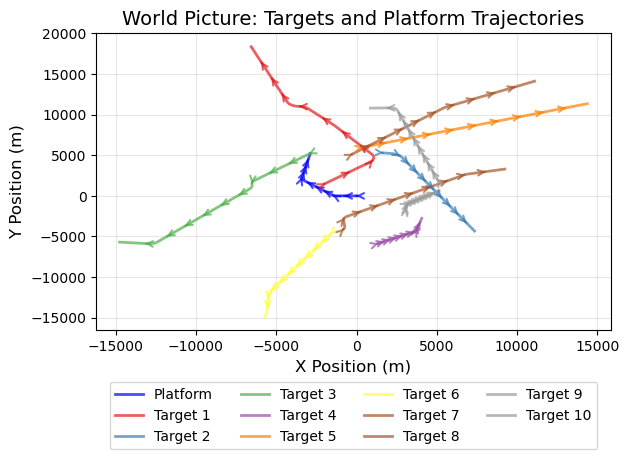

In [4]:
import matplotlib.pyplot as plt

timesteps = [
    SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    for i in range(SIM_PARAMS["num_steps"])
]

# Plot 2: Trajectories in Cartesian space
fig2, ax_path = plt.subplots()

# Extract platform positions
platform_x = []
platform_y = []
array_x = []
array_y = []

for timestamp in timesteps:
    platform_state = platform.get_platform_state_at(timestamp)
    platform_x.append(platform_state.host.state.state_vector[0])
    platform_y.append(platform_state.host.state.state_vector[2])
    
    array_center = np.mean(platform_state.array.state_vector, axis=1)
    array_x.append(array_center[0])
    array_y.append(array_center[1])

# Plot platform trajectory with direction arrows
ax_path.plot(platform_x, platform_y, 'b-', label='Platform', linewidth=2, alpha=0.7)
# ax_path.plot(array_x, array_y, 'g--', label='Array Center', linewidth=1.5, alpha=0.6)

# Add direction arrows for platform (every 10th point to avoid clutter)
arrow_interval = max(1, len(platform_x) // 10)
for i in range(0, len(platform_x) - 1, arrow_interval):
    dx = platform_x[i + 1] - platform_x[i]
    dy = platform_y[i + 1] - platform_y[i]
    ax_path.annotate('', xy=(platform_x[i + 1], platform_y[i + 1]), 
                    xytext=(platform_x[i], platform_y[i]),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.7))

# Plot target trajectories with different colors
colors = plt.cm.Set1(np.linspace(0, 1, NUM_TARGETS))

for target_idx, target_ground_truth in enumerate(target_ground_truths):
    target_x = [state.state_vector[0] for state in target_ground_truth]
    target_y = [state.state_vector[2] for state in target_ground_truth]
    
    color = colors[target_idx]
    ax_path.plot(target_x, target_y, '-', color=color, 
                label=f'Target {target_idx + 1}', linewidth=2, alpha=0.7)
    
    # Add direction arrows for each target (every 10th point)
    for i in range(0, len(target_x) - 1, arrow_interval):
        dx = target_x[i + 1] - target_x[i]
        dy = target_y[i + 1] - target_y[i]
        ax_path.annotate('', xy=(target_x[i + 1], target_y[i + 1]), 
                        xytext=(target_x[i], target_y[i]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.7))
    

ax_path.set_xlabel('X Position (m)', fontsize=12)
ax_path.set_ylabel('Y Position (m)', fontsize=12)
ax_path.set_title(f'World Picture: Targets and Platform Trajectories', fontsize=14)
ax_path.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=4)
ax_path.grid(True, alpha=0.3)
# ax_path.axis('equal')


plt.tight_layout()

# RUN SIMULATION WITH DETECTION

In [5]:
# ============================================================================
# RUN SIMULATION WITH DETECTION
# ============================================================================

data_generator = simulator.sensor_data_gen()

# Create detection chain
cfar_detector = CFARDetector(
    num_guard_cells=DET_PARAMS["cfar_detector"]["num_guard_cells"],
    num_training_cells=DET_PARAMS["cfar_detector"]["num_training_cells"],
    threshold_factor=DET_PARAMS["cfar_detector"]["threshold_factor"],
)
peak_detector = PeakDetector(distance=DET_PARAMS["peak_detector"]["distance"])

detection_chain = [cfar_detector]
detection_chain.append(peak_detector)

detector = PassiveSonarDetector(
    detection_chain=detection_chain,
    sensor_data_gen=data_generator,
    steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"]
)

# Run detection
print("Running detection chain...")
all_detections = list(detector.detections_gen(progress_bar=True))
snr_map = detector.snr_history

Running detection chain...


Generating Detections: 300it [07:42,  1.54s/it]


# VISUALIZATION

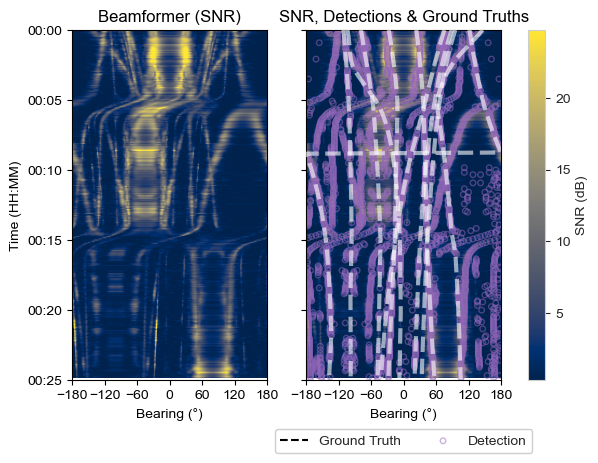

In [6]:
# ============================================================================
# VISUALIZATION
# ============================================================================

import matplotlib.pyplot as plt

timesteps = [
    SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    for i in range(SIM_PARAMS["num_steps"])
]

detections_for_plotter = [detection_set for _, detection_set in all_detections]

# Plot 1: Beamformer output with detections
fig1, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=[],
    ax=axs[0],
    add_colorbar=False
)
axs[0].set_title("Beamformer (SNR)")

# Right: SNR with detections and truth (exclude last timestep)
_, im = plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=detections_for_plotter[:-1],
    truths=relative_bearing_ground_truths,
    ax=axs[1],
    add_colorbar=False
)
axs[1].set_ylabel("")
axs[1].set_title(f"SNR, Detections & Ground Truths")

# Add shared colorbar
# im.set_clim(0, 10)
fig1.colorbar(im, ax=axs.tolist(), label='SNR (dB)')


(<Axes: xlabel='Bearing (°)', ylabel='Time (HH:MM)'>,
 <matplotlib.image.AxesImage at 0x7d207b784bf0>)

<Figure size 640x480 with 0 Axes>

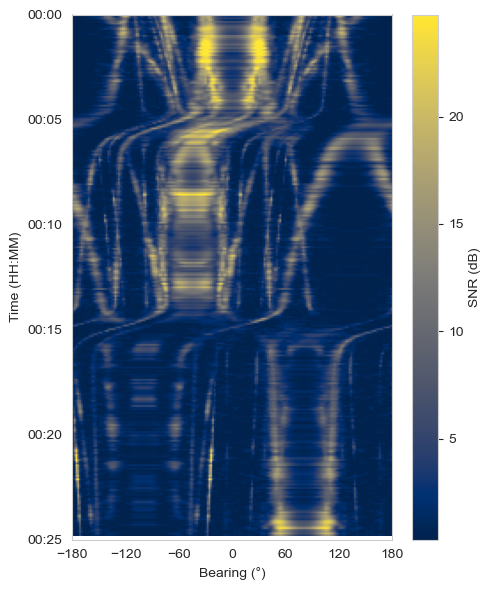

<Figure size 640x480 with 0 Axes>

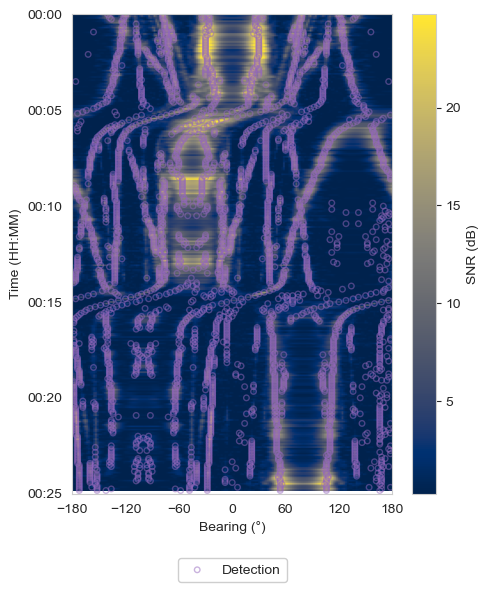

<Figure size 640x480 with 0 Axes>

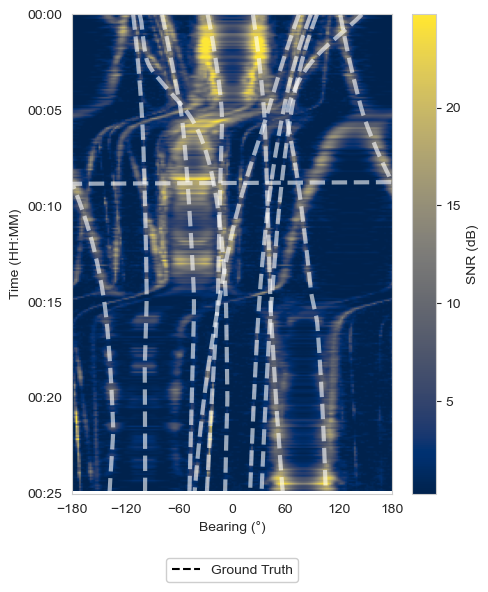

In [7]:
plt.figure()

style_guide = {
    "figure": {
        "figsize": (5, 6),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=[],
    add_colorbar=True
)

plt.figure()

style_guide = {
    "figure": {
        "figsize": (5, 6),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=detections_for_plotter[:-1],
    truths=[],
    add_colorbar=True
)

plt.figure()

style_guide = {
    "figure": {
        "figsize": (5, 6),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=relative_bearing_ground_truths,
    add_colorbar=True
)

## Create a new detection chain

Can reuse the same SNR map but apply a different detection chain to it. This allows you to experiment with different detection parameters without having to re-run the entire simulation.

This Detector has a lower threshold, and produces more true detections - but - more false alarms.

Text(0.5, 1.0, 'SNR - Low Threshold Detections')

<Figure size 640x480 with 0 Axes>

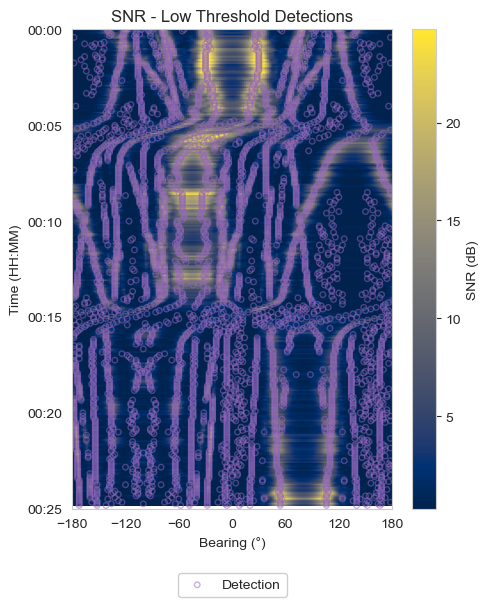

In [44]:
from stonesoup.types.detection import Detection

# Create a new detection chain with different parameters
new_cfar = CFARDetector(
    num_guard_cells=1,
    num_training_cells=4,
    threshold_factor=1.05, 
)
new_peak = PeakDetector(distance=2)

# new_detection_chain = [new_cfar]
new_detection_chain = [new_cfar, new_peak]

# Temporarily swap the detector's detection chain
original_chain = detector.detection_chain
detector.detection_chain = new_detection_chain

# Manually process the SNR map
new_detections = []
for i, snr_vector in enumerate(snr_map):
    timestamp = timesteps[i]
    detections_at_time = set()
    
    # Run NEW detection chain on this timestep's SNR
    raw_detections = detector._run_detection_chain(snr_vector)
    
    # Convert to Stone Soup Detections
    if raw_detections.size > 0:
        for raw_det in raw_detections:
            detection_index = int(raw_det[0])
            bearing_rad = BF_PARAMS["steering_azimuths_rad"][detection_index]
            
            detections_at_time.add(
                Detection(
                    state_vector=[[bearing_rad]],
                    timestamp=timestamp,
                    metadata={"snr_db": raw_det[1]},
                )
            )
    
    new_detections.append((timestamp, detections_at_time))

# Restore original detection chain
detector.detection_chain = original_chain

new_detections_for_plotter = [detection_set for _, detection_set in new_detections]

style_guide = {
    "figure": {
        "figsize": (5, 6),
        "font_size": 10
    }
}

plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))
plt.figure()

plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=new_detections_for_plotter[:-1],
    truths=[],
    add_colorbar=True
)
plt.title("SNR - Low Threshold Detections")

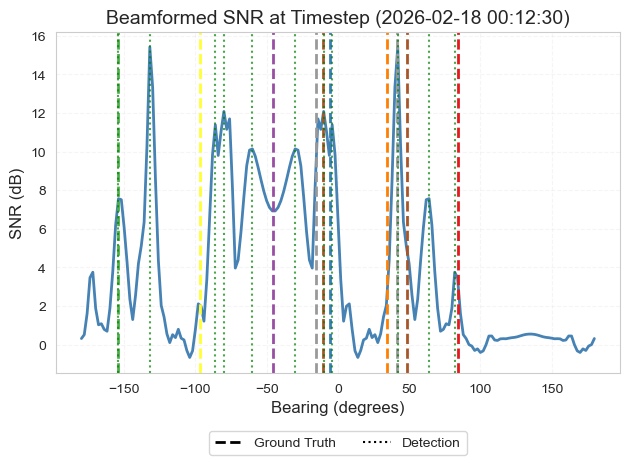

In [8]:
# Plot 3: Beamformed SNR at middle timestep
fig3, ax_middle = plt.subplots()

middle_timestep_idx = SIM_PARAMS["num_steps"] // 2
middle_snr = snr_map[middle_timestep_idx, :]
middle_time = timesteps[middle_timestep_idx]

steering_azimuths_deg = np.rad2deg(BF_PARAMS["steering_azimuths_rad"])
ax_middle.plot(steering_azimuths_deg, middle_snr, linewidth=2, color='steelblue')
ax_middle.set_xlabel('Bearing (degrees)', fontsize=12)
ax_middle.set_ylabel('SNR (dB)', fontsize=12)
ax_middle.set_title(f'Beamformed SNR at Timestep ({middle_time})', fontsize=14)
ax_middle.grid(True, alpha=0.3)

# Mark ground truth bearings for all targets
for target_idx, gt_relative_bearings in enumerate([
    [state.state_vector[0] for state in gt_path.states] 
    for gt_path in relative_bearing_ground_truths
]):
    gt_bearing_deg = np.rad2deg(gt_relative_bearings[middle_timestep_idx])
    color = colors[target_idx]
    ax_middle.axvline(gt_bearing_deg, color=color, linestyle='--', linewidth=2, 
                     label=f'Target {target_idx + 1} GT ({gt_bearing_deg:.1f}°)')

# Mark detections at this timestep if any
if len(detections_for_plotter[middle_timestep_idx]) > 0:
    for det_idx, det in enumerate(detections_for_plotter[middle_timestep_idx]):
        det_bearing_deg = np.rad2deg(det.state_vector[0])
        label = 'Detections' if det_idx == 0 else None
        ax_middle.axvline(det_bearing_deg, color='green', linestyle=':', linewidth=1.5, 
                        label=label, alpha=0.7)

# Create custom legend handles
from matplotlib.lines import Line2D
custom_handles = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Ground Truth'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=1.5, label='Detection')
]
ax_middle.legend(handles=custom_handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=2)
plt.tight_layout()

# STONE SOUP DETECTIONS

Generating Stone Soup detections with left-right ambiguity...


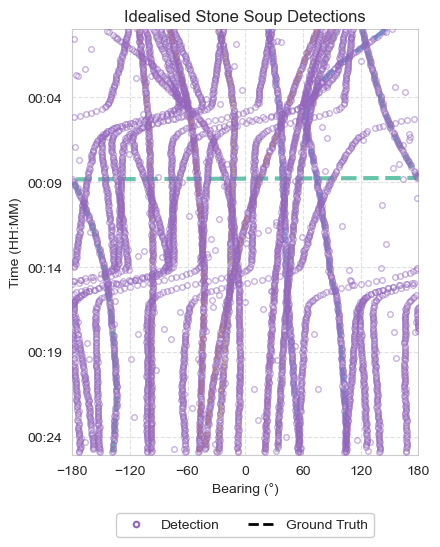

In [45]:
from stonesoup.types.detection import Detection
from scipy.stats import uniform
from stonesoup.models.measurement.linear import LinearGaussian

SS_DET_PARAMS = {
    "prob_detection": 0.95,
    "bearing_std_deg": 0.5,
    "fov_deg": 360.0,
    "expected_clutter_per_scan": 3,
    "include_ambiguity": True,
}

def compute_bearing_world_frame(platform_state, target_position):
    """Compute bearing from platform array center to target position in world frame."""
    array_center = np.mean(platform_state.array.state_vector, axis=1)
    relative_pos = target_position - array_center[:2]
    absolute_bearing = np.arctan2(relative_pos[1], relative_pos[0])
    return np.arctan2(np.sin(absolute_bearing), np.cos(absolute_bearing))

def generate_ambiguous_bearing(true_bearing_rad, platform_heading_rad):
    """Generate port/starboard ambiguous bearing."""
    ambiguous_bearing = 2 * platform_heading_rad - true_bearing_rad
    return np.arctan2(np.sin(ambiguous_bearing), np.cos(ambiguous_bearing))

# Measurement models
deg_std = SS_DET_PARAMS["bearing_std_deg"]
detection_measurement_model = LinearGaussian(
    ndim_state=1,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(deg_std)**2]])
)

ss_measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(deg_std)**2]])
)

# Detection parameters
prob_detection = SS_DET_PARAMS["prob_detection"]
FOV_RAD = np.deg2rad(SS_DET_PARAMS["fov_deg"])
expected_false_alarms_per_scan = SS_DET_PARAMS["expected_clutter_per_scan"]
clutter_spatial_density = expected_false_alarms_per_scan / FOV_RAD

print("Generating Stone Soup detections with left-right ambiguity...")
stone_soup_detections = []

for i, timestamp in enumerate(timesteps):
    detections_at_time = []
    
    # Generate true detections from each target
    for target_gt in target_ground_truths:
        target_state = target_gt[i]
        
        # Compute true bearing
        platform_state = platform.get_platform_state_at(timestamp)
        target_pos = np.array([target_state.state_vector[0], target_state.state_vector[2]])
        true_bearing = compute_bearing_world_frame(platform_state, target_pos)
        
        # Detection probability
        if np.random.rand() < prob_detection:
            # Generate noisy measurement for true bearing
            true_bearing_state = GroundTruthState(
                state_vector=np.array([true_bearing]),
                timestamp=timestamp
            )
            measurement = detection_measurement_model.function(true_bearing_state, noise=True)
            
            detection = Detection(
                state_vector=measurement,
                timestamp=timestamp,
                measurement_model=ss_measurement_model
            )
            detections_at_time.append(detection)
            
            # Generate ambiguous detection
            if SS_DET_PARAMS["include_ambiguity"]:
                platform_velocity = platform_state.host.state.state_vector[[1, 3]]
                platform_heading = np.arctan2(platform_velocity[1], platform_velocity[0])
                
                # ambiguous_bearing = generate_ambiguous_bearing(true_bearing, platform_heading)

                # Get array orientation from actual array geometry (not velocity)
                # The array axis points from tail to head of the array
                array_positions = platform_state.array.state_vector
                array_head = array_positions[:2, -1]  # Last sensor (head)
                array_tail = array_positions[:2, 0]   # First sensor (tail)
                array_axis = array_head - array_tail
                array_heading = np.arctan2(array_axis[1], array_axis[0])
                
                ambiguous_bearing = generate_ambiguous_bearing(true_bearing, array_heading)

                ambiguous_bearing_state = GroundTruthState(
                    state_vector=np.array([ambiguous_bearing]),
                    timestamp=timestamp
                )
                ambiguous_measurement = detection_measurement_model.function(
                    ambiguous_bearing_state, noise=True
                )
                
                ambiguous_detection = Detection(
                    state_vector=ambiguous_measurement,
                    timestamp=timestamp,
                    measurement_model=ss_measurement_model
                )
                detections_at_time.append(ambiguous_detection)
    
    # Add clutter
    num_clutter = np.random.poisson(clutter_spatial_density)
    for _ in range(num_clutter):
        clutter_bearing = uniform.rvs(loc=-np.pi, scale=2*np.pi)
        clutter_detection = Detection(
            state_vector=np.array([[clutter_bearing]]),
            timestamp=timestamp,
            measurement_model=ss_measurement_model
        )
        detections_at_time.append(clutter_detection)
    
    stone_soup_detections.append((timestamp, detections_at_time))

ss_detections_for_plotter = [detection_set for _, detection_set in stone_soup_detections]

style_guide = {
    "figure": {
        "figsize": (4.5, 5.5),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[],
    all_detections=ss_detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)

plt.title("Idealised Stone Soup Detections")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor='#9467bd', markersize=4, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
]

plt.legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, -0.12), ncol=4, 
              fancybox=True, shadow=False, frameon=True, framealpha=0.95)

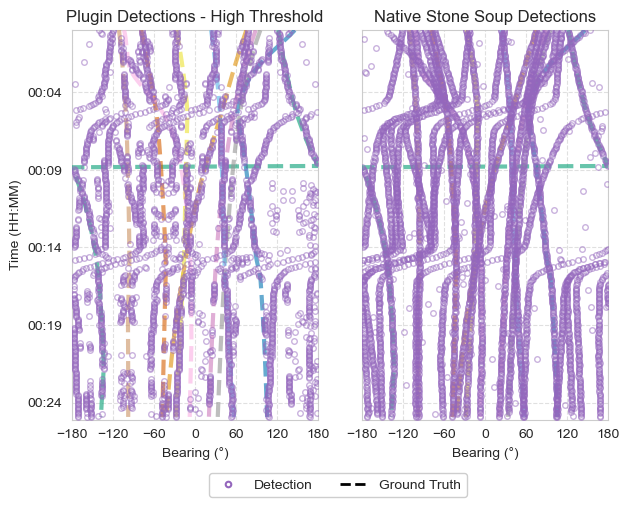

In [46]:
# plot nereus detections and ss detections side by side


fig1, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    },
    "legend": {
        "display": False,  # Disable legend on RHS plot
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[],
    all_detections=detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True,
    ax=axs[0],
)
axs[0].set_title("Plugin Detections - High Threshold")

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[],
    all_detections=ss_detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True,
    ax=axs[1],
)
axs[1].set_ylabel("")
axs[1].set_title(f"Native Stone Soup Detections")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor='#9467bd', markersize=4, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
]

plt.legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(-0.1, -0.12), ncol=2, 
              fancybox=True, shadow=False, frameon=True, framealpha=0.95)


<Figure size 640x480 with 0 Axes>

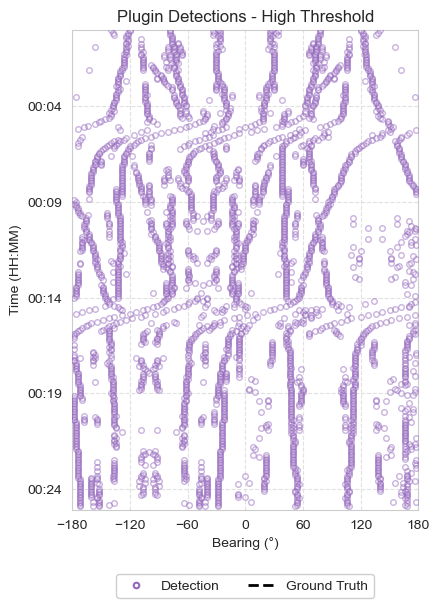

<Figure size 640x480 with 0 Axes>

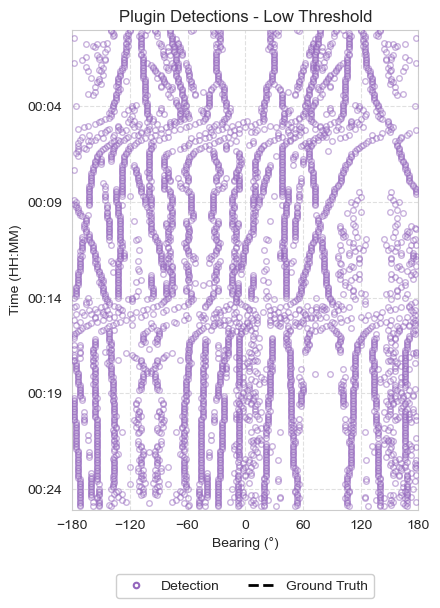

In [38]:
plt.figure()
style_guide = {
    "figure": {
        "figsize": (4.5, 5.5),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=[],
    tracks=[],
    all_detections=detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)

plt.title("Plugin Detections - High Threshold")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor='#9467bd', markersize=4, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
]

plt.legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, -0.12), ncol=4, 
              fancybox=True, shadow=False, frameon=True, framealpha=0.95)

plt.figure()
style_guide = {
    "figure": {
        "figsize": (4.5, 5.5),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=[],
    tracks=[],
    all_detections=new_detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)

plt.title("Plugin Detections - Low Threshold")

plt.legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, -0.12), ncol=4, 
              fancybox=True, shadow=False, frameon=True, framealpha=0.95)

# SUMMARY

In [12]:
print()
print("=" * 80)
print("Random Scenario Summary:")
print("=" * 80)
print(f"  Seed: {seed}")
print(f"  Number of Targets: {NUM_TARGETS}")
print(f"  Simulation Duration: {total_duration_s} s across {SIM_PARAMS['num_steps']} timesteps")
print(f"  Timestep Interval: {SIM_PARAMS['time_interval'].total_seconds()} s")
print(f"  Array: {ARRAY_PARAMS['num_sensors']} sensors, {ARRAY_PARAMS['sensor_spacing']} m spacing")
print(f"  Signal Sampling Rate: {SIGNAL_PARAMS['sampling_rate_hz']} Hz")
print(f"  Ambient Noise Level: {20 * np.log10(AMBIENT_NOISE_PARAMS['amplitude_upa']):.1f} dB re 1 µPa")
print(f"  Steering Directions: {len(BF_PARAMS['steering_azimuths_rad'])}")
print()
print("  Platform Initial State:")
print(f"    Position: ({SHIP_PARAMS['start_vector'][0]:.0f}, {SHIP_PARAMS['start_vector'][2]:.0f}) m")
print(f"    Velocity: ({SHIP_PARAMS['start_vector'][1]:.1f}, {SHIP_PARAMS['start_vector'][3]:.1f}) m/s")
print()
print(f"  Platform Maneuvers ({len(maneuver_models)} total):")
for i, desc in enumerate(maneuver_descriptions):
    print(f"    {i+1}. {desc} @ timestep {maneuver_durations[i]}")
print()
for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    print(f"  Target {target_idx + 1}:")
    print(f"    Frequencies: {TARGET_PARAMS['frequencies_hz']} Hz")
    print(f"    Amplitudes: {20 * np.log10(TARGET_PARAMS['amplitudes_upa'])} dB re 1 µPa")
    print(f"    Start Position: ({TARGET_PARAMS['start_vector'][0]:.0f}, {TARGET_PARAMS['start_vector'][2]:.0f}) m")
    print(f"    Velocity: ({TARGET_PARAMS['start_vector'][1]:.1f}, {TARGET_PARAMS['start_vector'][3]:.1f}) m/s")



Random Scenario Summary:
  Seed: 12
  Number of Targets: 10
  Simulation Duration: 1500.0 s across 300 timesteps
  Timestep Interval: 5.0 s
  Array: 250 sensors, 1.0 m spacing
  Signal Sampling Rate: 500.0 Hz
  Ambient Noise Level: 52.9 dB re 1 µPa
  Steering Directions: 181

  Platform Initial State:
    Position: (0, 0) m
    Velocity: (-5.0, 0.0) m/s

  Platform Maneuvers (9 total):
    1. Straight (255s) @ timestep 0:04:15
    2. Right Turn 44° (45s) @ timestep 0:00:45
    3. Straight (285s) @ timestep 0:04:45
    4. Straight (240s) @ timestep 0:04:00
    5. Right Turn 1° (0s) @ timestep 0:00:00
    6. Right Turn 57° (55s) @ timestep 0:00:55
    7. Straight (130s) @ timestep 0:02:10
    8. Straight (285s) @ timestep 0:04:45
    9. Straight (205s) @ timestep 0:03:25

  Target 1:
    Frequencies: [ 95.11053479 199.14917806  56.07373079 193.45445803] Hz
    Amplitudes: [98.51213476 99.3751388  93.09960453 93.76962617] dB re 1 µPa
    Start Position: (-1984, 1495) m
    Velocity: (10.